In [ ]:
# Benchmarking large-scale integration

In [ ]:
#!pip install scvi-tools

In [ ]:
#!pip install scib-metrics

In [1]:
import numpy as np
import scanpy as sc
from scvi.data import cellxgene

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

%matplotlib inline

In [2]:
# open the anndata object
adata= sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/integration/Benchmark_Integration/seurat_integrated.h5ad")

In [3]:
# inspect adata
adata

AnnData object with n_obs × n_vars = 67995 × 19631
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'timepoint', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'
    uns: 'timepoint_colors'
    obsm: 'X_pca', 'X_umap', 'X_umap_cca', 'X_umap_harmony'

In [6]:
import scanpy as sc

# Check if HVGs exist
print(adata.var.columns)

# If not, compute HVGs
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

# Subset to HVGs
adata = adata[:, adata.var.highly_variable].copy()


Index([], dtype='object')


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [8]:
# This creates a new key in the obsm dictionary of the AnnData object called "Unintegrated".
# It stores a copy of the PCA representation (X_pca) under that new key.

# Why it's useful:
    #"Unintegrated" is often used as a label for the original, uncorrected embedding, especially in benchmarking workflows.
# It allows you to compare the pre-integration PCA (which may reflect batch effects) with post-integration embeddings (like X_scVI), which are supposed to be batch-corrected.
adata.obsm["Unintegrated"] = adata.obsm["X_pca"]

In [9]:
adata

AnnData object with n_obs × n_vars = 67995 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'timepoint', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'timepoint_colors', 'hvg'
    obsm: 'X_pca', 'X_umap', 'X_umap_cca', 'X_umap_harmony', 'Unintegrated'

In [11]:
# For a beautified visualization you can change the matplotlib settings
import scvelo as scv
scv.set_figure_params()

In [12]:
import scanpy as sc

# Use the 'Unintegrated' PCA as the basis for UMAP
sc.pp.neighbors(adata, use_rep="Unintegrated")
sc.tl.umap(adata)
# save UMAP separately so it's not overwritten later
adata.obsm["X_umap_unintegrated"] = adata.obsm["X_umap"].copy()

In [13]:
print(adata.obs.columns)

Index(['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'timepoint', 'unintegrated_clusters', 'seurat_clusters',
       'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'],
      dtype='object')


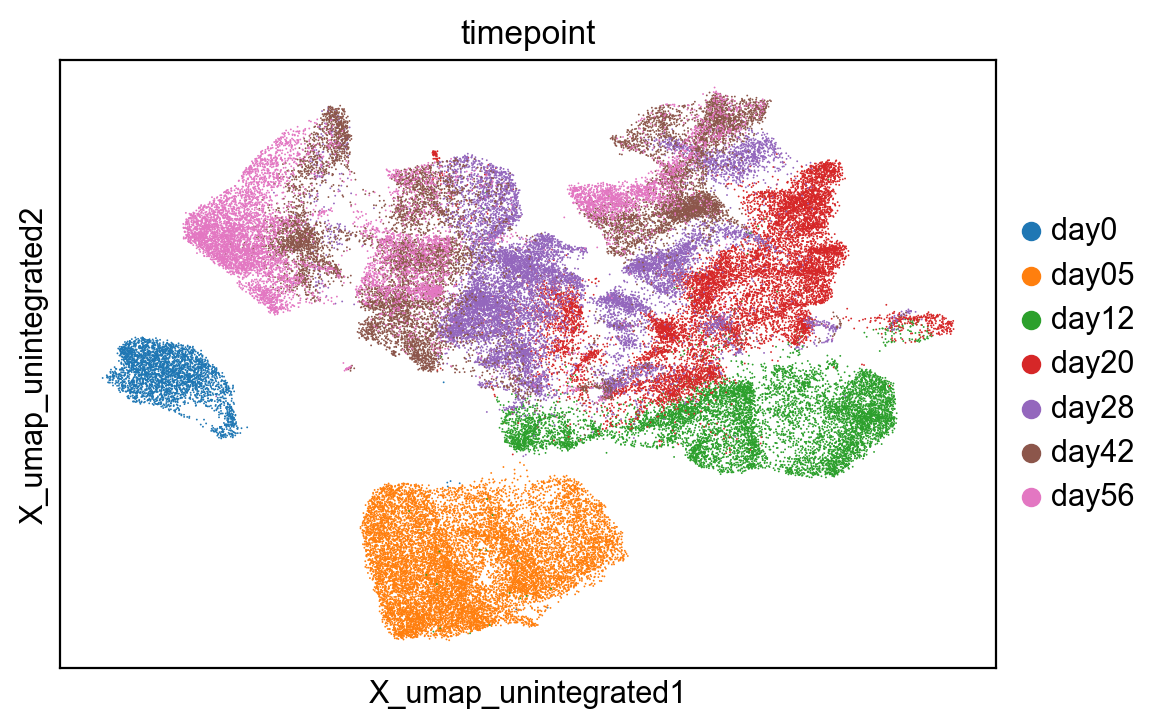

In [15]:
sc.pl.embedding(adata, basis="X_umap_unintegrated", color="timepoint")  # or "leiden", "_scvi_batch", etc.

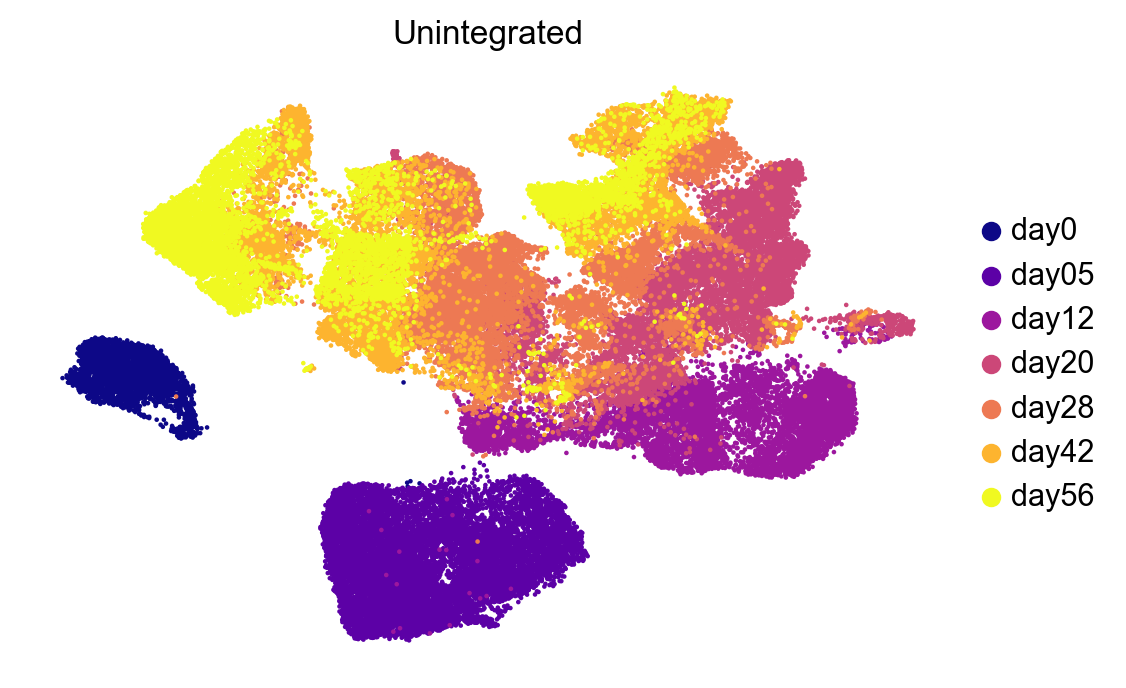

In [23]:
import scvelo as scv

# Backup original UMAP embedding
adata.obsm["_X_umap_backup"] = adata.obsm["X_umap"].copy()

# Replace X_umap with unintegrated UMAP
adata.obsm["X_umap"] = adata.obsm["X_umap_unintegrated"]

# Plot using scvelo with figsize 4x4
scv.pl.umap(
    adata, 
    color=["timepoint"], 
    wspace=0.1, 
    title="Unintegrated", 
    legend_loc="right margin", 
    palette="plasma", 
    figsize=(6, 4)
)

# Restore original UMAP embedding
adata.obsm["X_umap"] = adata.obsm["_X_umap_backup"]
del adata.obsm["_X_umap_backup"]

In [17]:
adata

AnnData object with n_obs × n_vars = 67995 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'timepoint', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'timepoint_colors', 'hvg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_cca', 'X_umap_harmony', 'Unintegrated', 'X_umap_unintegrated'
    obsp: 'distances', 'connectivities'

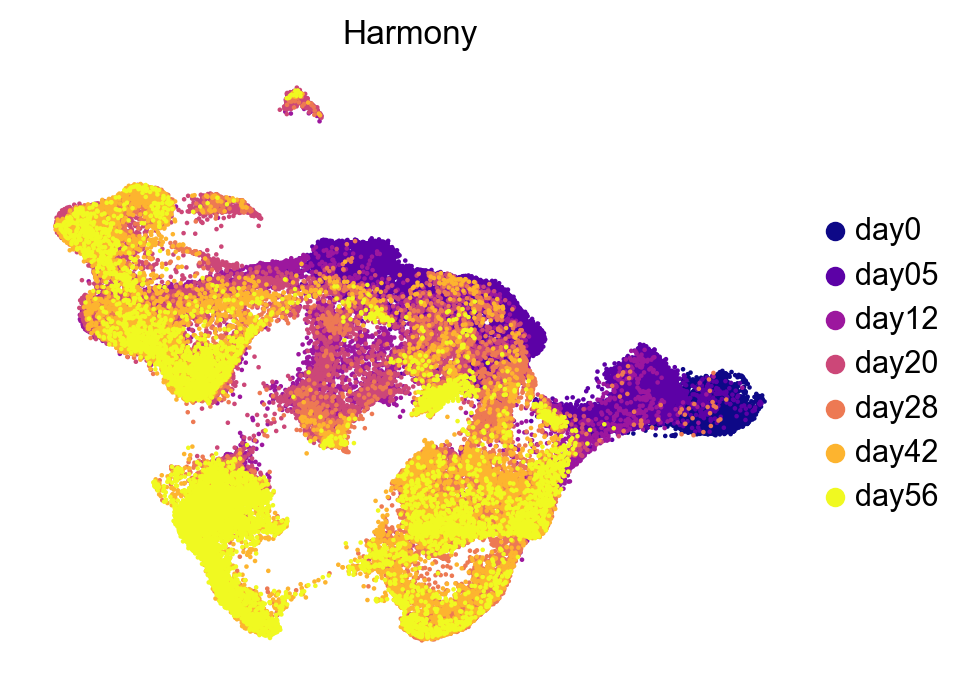

In [20]:
import scvelo as scv

# Backup original UMAP
adata.obsm["_X_umap_backup"] = adata.obsm["X_umap"].copy()

# Use Scanorama UMAP for plotting
adata.obsm["X_umap"] = adata.obsm["X_umap_harmony"]

# Plot using scVelo styling
scv.pl.umap(
    adata,
    color=["timepoint"],                 # You can change this to 'batch', 'leiden', etc.
    title="Harmony",
    legend_loc="right margin",
    palette="plasma",
    wspace=0.1,
    figsize=(5, 4)
)
#color=["leiden"]  # or ["cell_type"]

# Restore original UMAP (optional but recommended)
adata.obsm["X_umap"] = adata.obsm["_X_umap_backup"]
del adata.obsm["_X_umap_backup"]

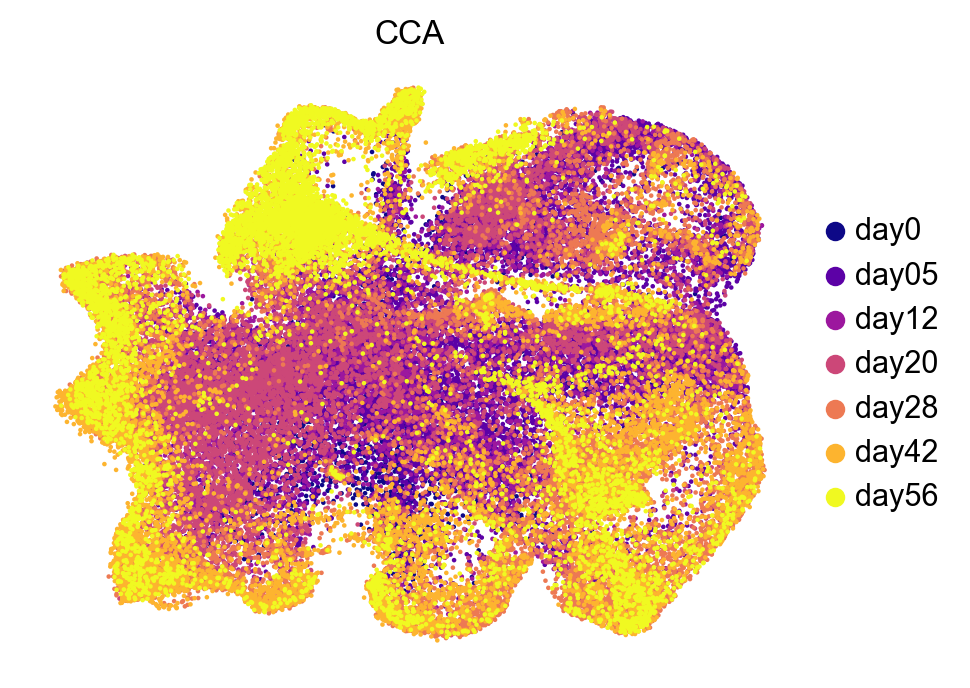

In [21]:
import scvelo as scv

# Backup original UMAP
adata.obsm["_X_umap_backup"] = adata.obsm["X_umap"].copy()

# Use Scanorama UMAP for plotting
adata.obsm["X_umap"] = adata.obsm["X_umap_cca"]

# Plot using scVelo styling
scv.pl.umap(
    adata,
    color=["timepoint"],                 # You can change this to 'batch', 'leiden', etc.
    title="CCA",
    legend_loc="right margin",
    palette="plasma",
    wspace=0.1,
    figsize=(5, 4)
)
#color=["leiden"]  # or ["cell_type"]

# Restore original UMAP (optional but recommended)
adata.obsm["X_umap"] = adata.obsm["_X_umap_backup"]
del adata.obsm["_X_umap_backup"]

In [26]:
print(adata.obs.columns)

Index(['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'timepoint', 'unintegrated_clusters', 'seurat_clusters',
       'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'],
      dtype='object')


In [27]:
adata

AnnData object with n_obs × n_vars = 67995 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'timepoint', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'timepoint_colors', 'hvg', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_cca', 'X_umap_harmony', 'Unintegrated', 'X_umap_unintegrated'
    obsp: 'distances', 'connectivities'

In [28]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_cca, X_umap_harmony, Unintegrated, X_umap_unintegrated)


In [30]:
# check adata if batch exists
print(adata.obs.columns)

Index(['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'timepoint', 'unintegrated_clusters', 'seurat_clusters',
       'harmony_clusters', 'cca_clusters', 'barcode', 'UMAP_1', 'UMAP_2'],
      dtype='object')


In [31]:
# Use 'Sample' as the batch column
adata.obs["batch"] = adata.obs["timepoint"].astype("category")

In [32]:
# quick sanity check
print(adata.obs["batch"].value_counts())

batch
day28    12964
day05    12270
day42    11513
day20    11308
day56     8379
day12     8360
day0      3201
Name: count, dtype: int64


In [38]:
bm = Benchmarker(
    adata,
    batch_key="batch",                      # Make sure this exists (yes, timepoint)!
    label_key="seurat_clusters",           # Seurat-based biological clusters
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=[
        "X_umap_cca",
        "X_umap_harmony",
        "X_umap_unintegrated"
    ],
    n_jobs=6,
)

bm.benchmark()

Metrics:   0%|        | 0/10 [00:00<?, ?it/s, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [00:02<00:18,  2.07s/it, Bio conservation: isolated_labels
Metrics:  10%| | 1/10 [00:02<00:18,  2.07s/it, Bio conservation: nmi_ari_cluster
Metrics:  20%|▏| 2/10 [00:03<00:12,  1.57s/it, Bio conservation: nmi_ari_cluster
Metrics:  20%|▏| 2/10 [00:03<00:12,  1.57s/it, Bio conservation: silhouette_labe
Metrics:  30%|▎| 3/10 [00:05<00:12,  1.82s/it, Bio conservation: silhouette_labe
Metrics:  70%|▋| 7/10 [00:25<00:20,  6.81s/it, Batch correction: kbet_per_label]
Metrics:  70%|▋| 7/10 [00:25<00:20,  6.81s/it, Batch correction: graph_connectiv
Embeddings:  33%|███████████                      | 1/3 [00:25<00:51, 25.80s/it]
                                                                                
Metrics:   0%|        | 0/10 [00:00<?, ?it/s, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [00:02<00:19,  2.17s/it, Bio conservation: isolated_labels
Metrics:  10%| | 1/10 [00:02

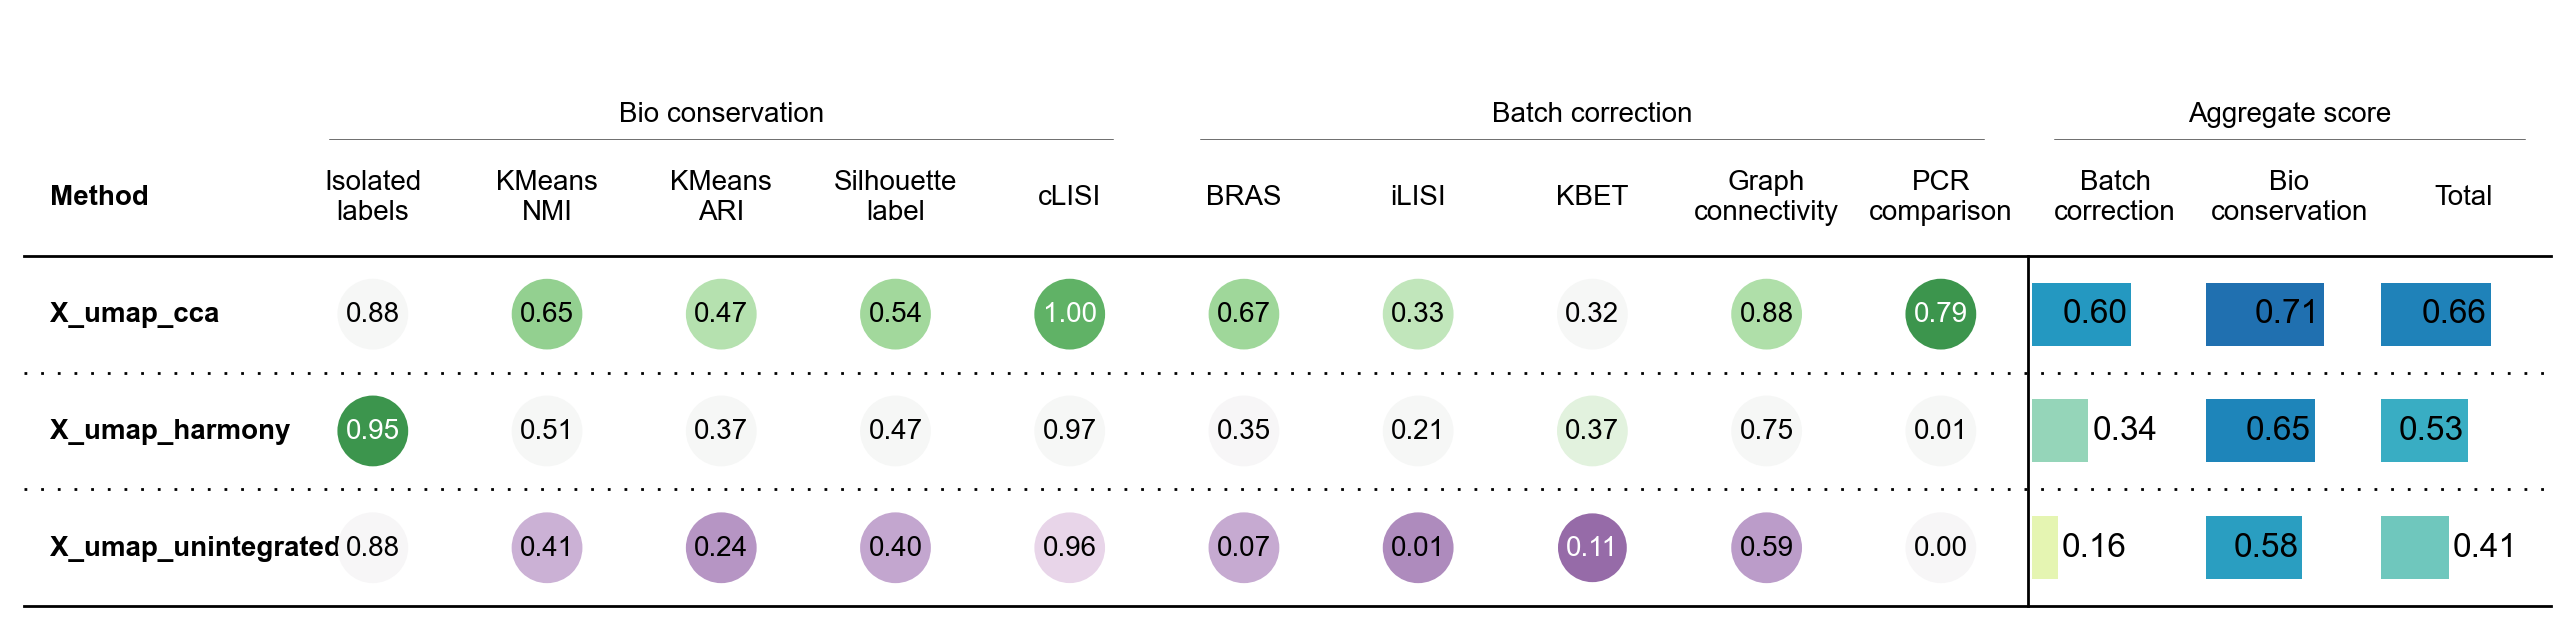

In [39]:
bm.plot_results_table()

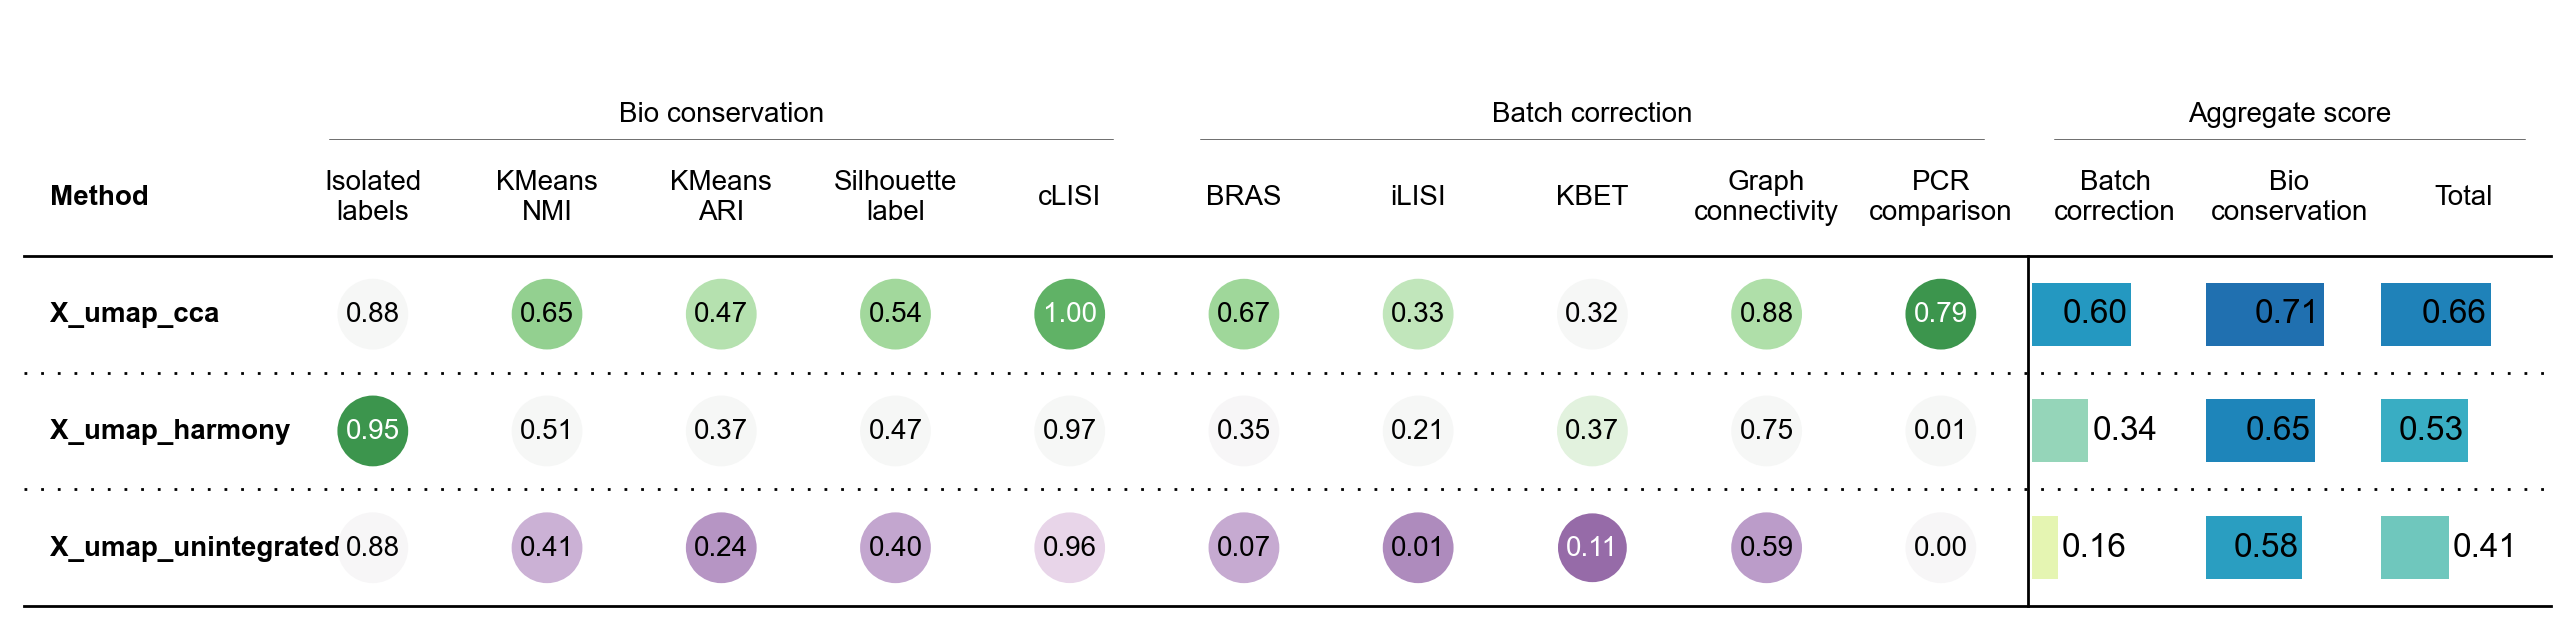

In [40]:
bm.plot_results_table(min_max_scale=False)

In [41]:
# Saving an AnnData object
adata.write("/Users/ogjaime/Desktop/CellRank/integration/Scvi/seurat_integrated.h5ad")